# 13 — Baseline: Random Forest SDM

Patch-level Random Forest for all species above a minimum occurrence threshold.
This serves as the baseline for comparison with GNN-SDM.

For each species: label patches as presence/absence, train RF on patch mean
features, evaluate with 5-fold cross-validated AUC. No hyperparameter tuning.

### Load data

In [1]:
import config
import numpy as np
import pandas as pd
import json
import time
from s3_utils import load_zarr
from rasterio.transform import rowcol
import rioxarray

# Patch labels raster
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
patch_labels = patch_labels_da.values
transform = patch_labels_da.rio.transform()

# Patch features
patch_features = np.load('patch_features.npy')
with open('patch_feature_names.json') as f:
    feature_names = json.load(f)

n_patches = patch_features.shape[0]
print(f'Patches: {n_patches:,}, features: {len(feature_names)}')

# GBIF occurrences
gbif = pd.read_parquet(config.GBIF_PARQUET, storage_options={'anon': False})
print(f'GBIF records: {len(gbif):,}')


Patches: 166,464, features: 12
GBIF records: 22,723,973


### Select species and map occurrences to patches

In [2]:
MIN_RECORDS = 100  # minimum GBIF records to include a species

# Count records per species
species_counts = gbif['species'].value_counts()
candidate_species = species_counts[species_counts >= MIN_RECORDS].index.tolist()
print(f'Species with >= {MIN_RECORDS} records: {len(candidate_species):,}')
t0 = time.time()

# 1. Map ALL GBIF records to row/col indices in one shot
print("Transforming all coordinates...")
rows, cols = rowcol(transform, gbif['decimallongitude'].values,
                    gbif['decimallatitude'].values)
rows, cols = np.array(rows), np.array(cols)

# 2. Check bounds
h, w = patch_labels.shape
valid = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)

# 3. Lookup patch IDs for every valid record
gbif_patch_ids = np.full(len(gbif), -1, dtype=np.int32)
gbif_patch_ids[valid] = patch_labels[rows[valid], cols[valid]]
gbif['patch_id'] = gbif_patch_ids

# 4. Aggregate unique patches per species
print("Aggregating species patches...")
species_patch_groups = (
    gbif[gbif['patch_id'] >= 0]
    .groupby('species')['patch_id']
    .unique()
)

# 5. Filter
species_patches = {
    sp: set(patches)
    for sp, patches in species_patch_groups.items()
    if species_counts.get(sp, 0) >= MIN_RECORDS
}

elapsed = time.time() - t0
print(f'Done in {elapsed:.0f}s')


# Quick stats
patch_counts_per_sp = [len(p) for p in species_patches.values()]
print(f'Presence patches per species: '
      f'min={min(patch_counts_per_sp)}, '
      f'median={int(np.median(patch_counts_per_sp))}, '
      f'max={max(patch_counts_per_sp):,}')


Species with >= 100 records: 3,756
Transforming all coordinates...
Aggregating species patches...
Done in 10s
Presence patches per species: min=1, median=341, max=15,671


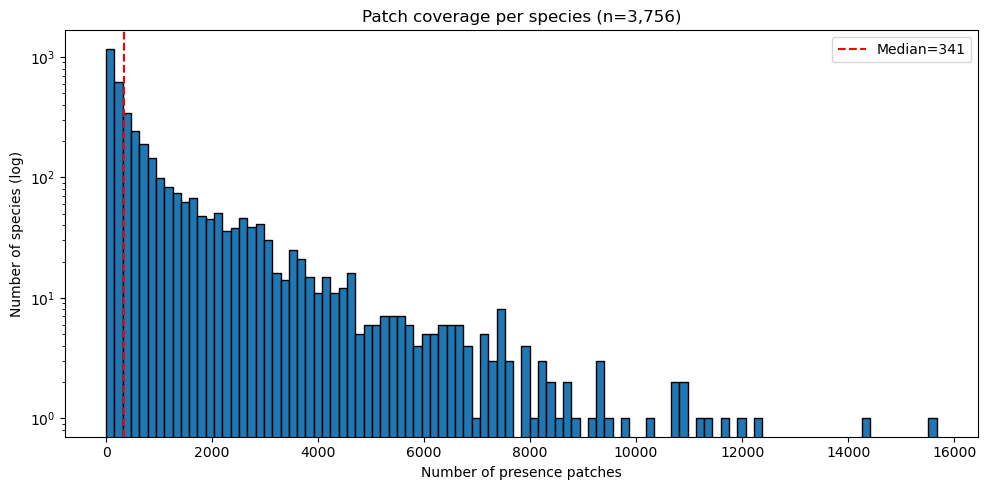

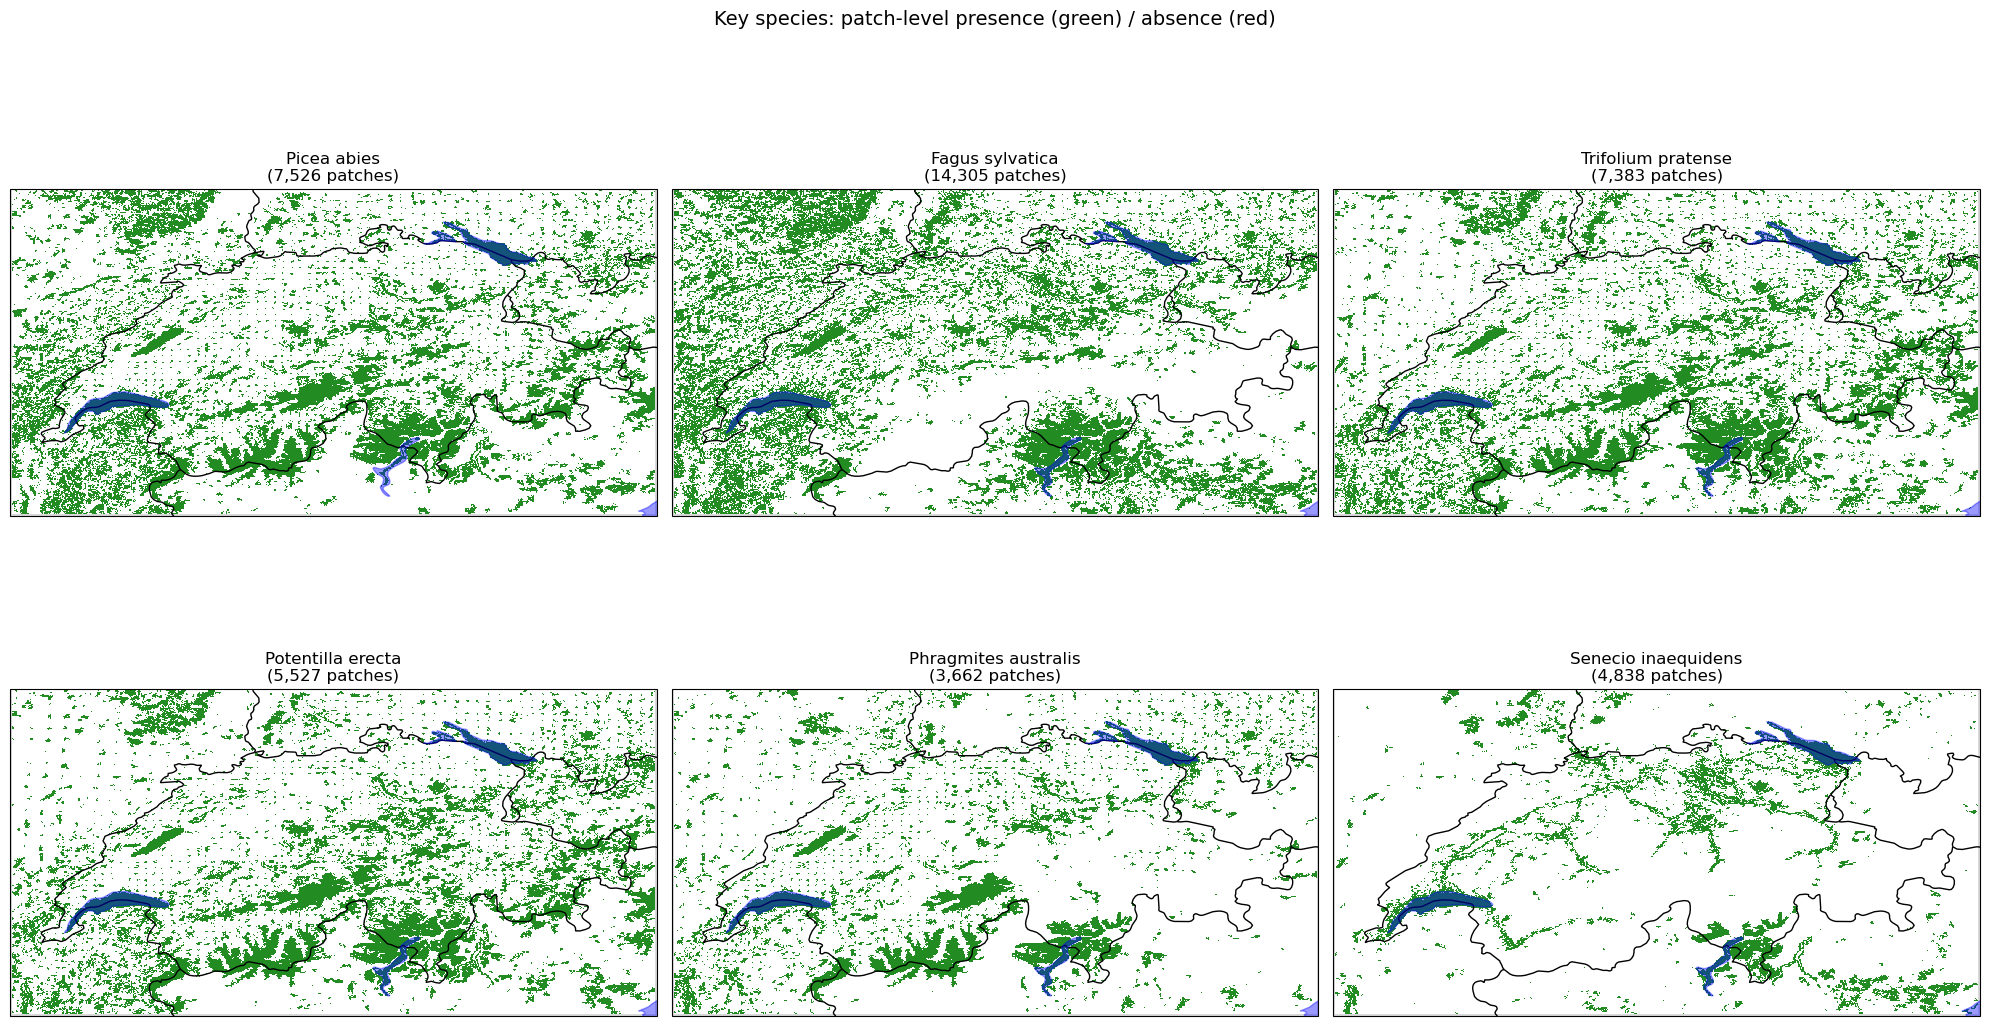

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from geo_utils import BOUNDS, apply_map_decor
from matplotlib.colors import ListedColormap

# --- 1. Distribution of patches per species ---
patch_counts_per_sp = [len(p) for p in species_patches.values()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(patch_counts_per_sp, bins=100, log=True, edgecolor='black')
ax.set_xlabel('Number of presence patches')
ax.set_ylabel('Number of species (log)')
ax.set_title(f'Patch coverage per species (n={len(species_patches):,})')
ax.axvline(np.median(patch_counts_per_sp), color='red', linestyle='--',
           label=f'Median={int(np.median(patch_counts_per_sp)):,}')
ax.legend()
plt.tight_layout()
plt.show()

# --- 2. Maps for key species ---
KEY_SPECIES = [
    'Picea abies', 'Fagus sylvatica', 'Trifolium pratense',
    'Potentilla erecta', 'Phragmites australis', 'Senecio inaequidens',
]

step = 20
extent = [BOUNDS['lon_min'], BOUNDS['lon_max'],
          BOUNDS['lat_min'], BOUNDS['lat_max']]

fig, axes = plt.subplots(2, 3, figsize=(20, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})

for ax, sp in zip(axes.flat, KEY_SPECIES):
    presence = species_patches.get(sp, set())
    # Build a binary presence map
    pres_mask = np.isin(patch_labels, list(presence)) & (patch_labels >= 0)
    display = np.where(pres_mask, 1, np.where(patch_labels >= 0, 0, np.nan))
        # 1 = present (green), 0 = absent (white), NaN = nodata (grey)
    display = np.where(pres_mask, 1.0, np.where(patch_labels >= 0, 0.0, np.nan))
    cmap_pres = ListedColormap(['white', 'forestgreen'])

    ax.imshow(display[::step, ::step], cmap=cmap_pres, vmin=0, vmax=1,
              extent=extent, origin='upper', interpolation='nearest',
              transform=ccrs.PlateCarree())
    ax.set_facecolor('#d9d9d9')  # grey background for nodata

    apply_map_decor(ax, f'{sp}\n({len(presence):,} patches)')

plt.suptitle('Key species: patch-level presence (green) / absence (red)', fontsize=14)
plt.tight_layout()
plt.show()


### Hyperparameter tuning on key species

Quick grid search on the 6 representative species to find reasonable RF settings.
These will then be used for the full species run.


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, cohen_kappa_score, recall_score

KEY_SPECIES = [
    'Picea abies', 'Fagus sylvatica', 'Trifolium pratense',
    'Potentilla erecta', 'Phragmites australis', 'Senecio inaequidens',
]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5, 10],
}

rng = np.random.default_rng(42)
all_ids = np.arange(n_patches)
tuning_results = []

for sp in KEY_SPECIES:
    presence = np.array(list(species_patches[sp]))
    n_pres = len(presence)
    absence = np.setdiff1d(all_ids, presence)
    n_abs = min(len(absence), n_pres * 3)
    absence_sample = rng.choice(absence, n_abs, replace=False)

    idx = np.concatenate([presence, absence_sample])
    X = patch_features[idx]
    y = np.concatenate([np.ones(n_pres), np.zeros(n_abs)])
    finite = np.isfinite(X).all(axis=1)
    X, y = X[finite], y[finite]

    gs = GridSearchCV(
        RandomForestClassifier(n_jobs=-1, random_state=42),
        param_grid, cv=5, scoring='roc_auc', n_jobs=1,
    )
    gs.fit(X, y)

    tuning_results.append({
        'species': sp,
        'best_auc': gs.best_score_,
        **gs.best_params_,
    })
    print(f'{sp:30s}  AUC={gs.best_score_:.3f}  {gs.best_params_}')

tuning_df = pd.DataFrame(tuning_results)
print('\n--- Summary ---')
print(tuning_df.to_string(index=False))

# Majority vote for best params
from collections import Counter
best_params = {}
for param in param_grid:
    values = tuning_df[param].tolist()
    best_params[param] = Counter(values).most_common(1)[0][0]

print(f'\nSelected params (majority vote): {best_params}')


Picea abies                     AUC=0.773  {'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 300}
Fagus sylvatica                 AUC=0.786  {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 300}
Trifolium pratense              AUC=0.730  {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 300}
Potentilla erecta               AUC=0.755  {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 300}
Phragmites australis            AUC=0.788  {'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 300}
Senecio inaequidens             AUC=0.911  {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}

--- Summary ---
             species  best_auc  max_depth  min_samples_leaf  n_estimators
         Picea abies  0.773130         20                10           300
     Fagus sylvatica  0.786290         10                10           300
  Trifolium pratense  0.729520         10                 5           300
   Potentilla erecta  0.755317         10            

### Train RF for all species

In [3]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, cohen_kappa_score, recall_score

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, cohen_kappa_score, recall_score
import os

def tss_score(y_true, y_pred):
    """True Skill Statistic = sensitivity + specificity - 1"""
    sensitivity = recall_score(y_true, y_pred)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    return sensitivity + specificity - 1

scoring = {
    'auc': 'roc_auc',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'mcc': make_scorer(matthews_corrcoef),
    'kappa': make_scorer(cohen_kappa_score),
    'tss': make_scorer(tss_score),
}

CHECKPOINT_FILE = 'baseline_rf_checkpoint.csv'
CHECKPOINT_EVERY = 50

best_params = {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 10}

# Resume from checkpoint
if os.path.exists(CHECKPOINT_FILE):
    done_df = pd.read_csv(CHECKPOINT_FILE)
    results = done_df.to_dict('records')
    done_species = set(done_df['species'])
    print(f'Resuming: {len(done_species)} species already done')
else:
    results = []
    done_species = set()

rng = np.random.default_rng(42)
all_ids = np.arange(n_patches)
species_list = [sp for sp in species_patches if sp not in done_species]

print(f'Training RF for {len(species_list)} remaining species...')
t0 = time.time()

for i, sp in enumerate(species_list):
    presence = np.array(list(species_patches[sp]))
    n_pres = len(presence)
    absence = np.setdiff1d(all_ids, presence)
    n_abs = min(len(absence), n_pres * 3)
    absence_sample = rng.choice(absence, n_abs, replace=False)

    idx = np.concatenate([presence, absence_sample])
    X = patch_features[idx]
    y = np.concatenate([np.ones(n_pres), np.zeros(n_abs)])
    finite = np.isfinite(X).all(axis=1)
    X, y = X[finite], y[finite]

    n_minority = min(int(y.sum()), int((1 - y).sum()))
    if n_minority < 5 or len(np.unique(y)) < 2:
        continue

    rf = RandomForestClassifier(**best_params, n_jobs=-1, random_state=42)
    cv = cross_validate(rf, X, y, cv=5, scoring=scoring)

    results.append({
        'species': sp,
        'n_records': int(species_counts[sp]),
        'n_presence_patches': n_pres,
        'auc_mean': cv['test_auc'].mean(),
        'auc_std': cv['test_auc'].std(),
        'accuracy_mean': cv['test_accuracy'].mean(),
        'precision_mean': cv['test_precision'].mean(),
        'recall_mean': cv['test_recall'].mean(),
        'f1_mean': cv['test_f1'].mean(),
        'mcc_mean': cv['test_mcc'].mean(),
        'kappa_mean': cv['test_kappa'].mean(),
        'tss_mean': cv['test_tss'].mean(),
    })

    if (i + 1) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (len(species_list) - i - 1)
        print(f'  {i+1}/{len(species_list)}  '
              f'elapsed={elapsed:.0f}s  ETA={eta:.0f}s  '
              f'checkpoint ({len(results)} species)')

pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
elapsed = time.time() - t0
print(f'\nDone: {len(results)} species in {elapsed:.0f}s ({elapsed/60:.1f} min)')


Resuming: 3536 species already done
Training RF for 220 remaining species...
  50/220  elapsed=147s  ETA=500s  checkpoint (3581 species)
  100/220  elapsed=299s  ETA=359s  checkpoint (3631 species)
  150/220  elapsed=465s  ETA=217s  checkpoint (3681 species)
  200/220  elapsed=614s  ETA=61s  checkpoint (3731 species)

Done: 3751 species in 666s (11.1 min)


### Results

Species evaluated: 3751

Metric summary across all species:
  auc_mean              mean=0.838  median=0.834  std=0.061
  accuracy_mean         mean=0.812  median=0.804  std=0.038
  precision_mean        mean=0.715  median=0.713  std=0.110
  recall_mean           mean=0.395  median=0.369  std=0.175
  f1_mean               mean=0.489  median=0.482  std=0.161
  mcc_mean              mean=0.428  median=0.412  std=0.148
  kappa_mean            mean=0.395  median=0.376  std=0.161
  tss_mean              mean=0.346  median=0.318  std=0.165


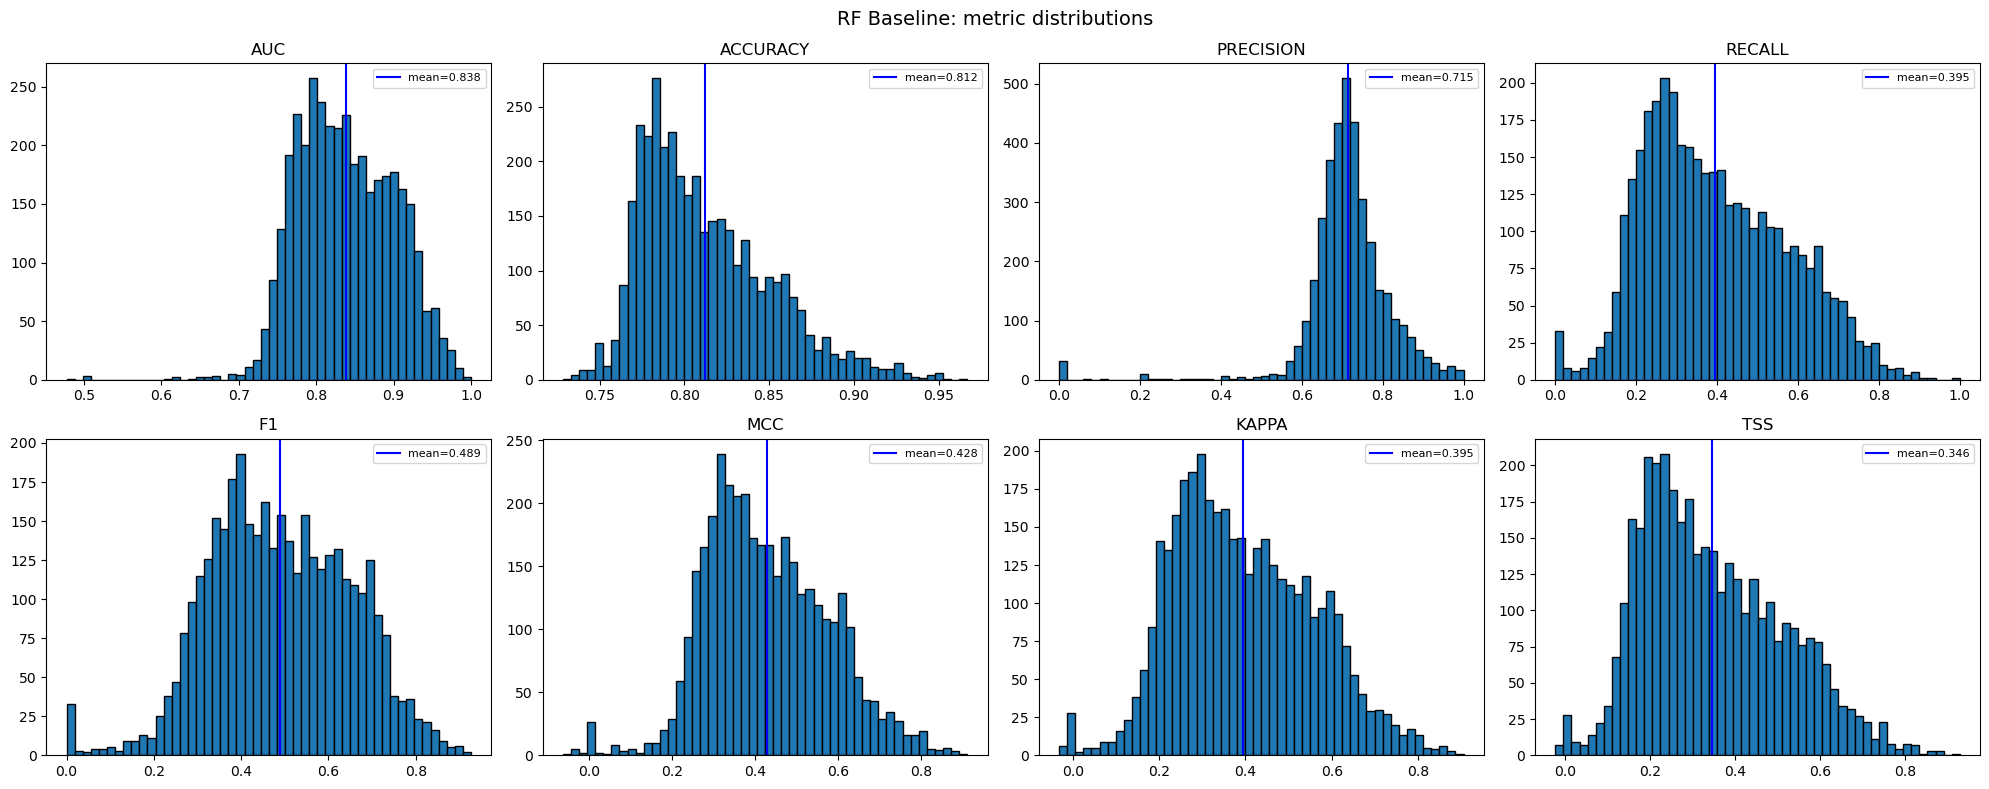

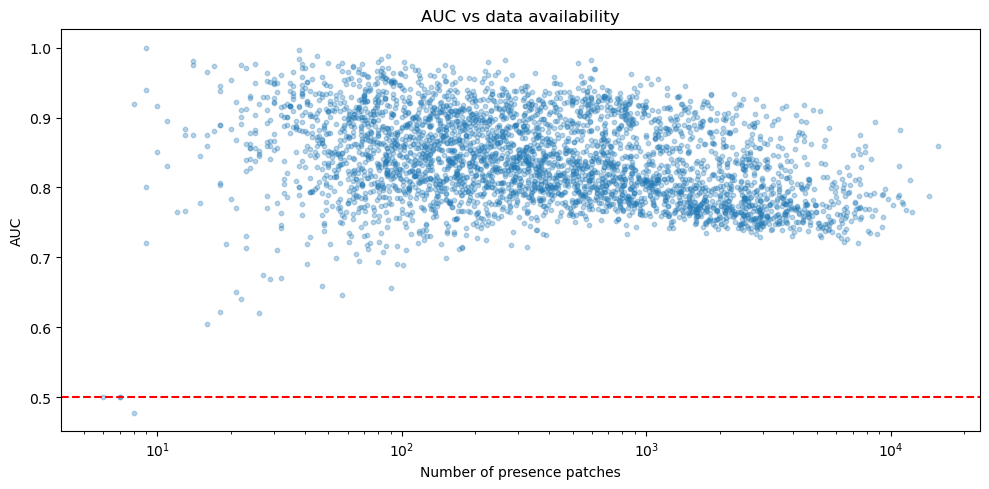

Saved baseline_rf_results.csv (3751 species)


In [4]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results).sort_values('auc_mean', ascending=False)

metrics = ['auc_mean', 'accuracy_mean', 'precision_mean', 'recall_mean',
           'f1_mean', 'mcc_mean', 'kappa_mean', 'tss_mean']

print(f'Species evaluated: {len(res_df)}')
print(f'\nMetric summary across all species:')
for m in metrics:
    print(f'  {m:20s}  mean={res_df[m].mean():.3f}  '
          f'median={res_df[m].median():.3f}  '
          f'std={res_df[m].std():.3f}')

# Distribution of key metrics
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, m in zip(axes.flat, metrics):
    ax.hist(res_df[m], bins=50, edgecolor='black')
    ax.axvline(res_df[m].mean(), color='blue', linestyle='-',
               label=f'mean={res_df[m].mean():.3f}')
    ax.set_title(m.replace('_mean', '').upper())
    ax.legend(fontsize=8)
plt.suptitle('RF Baseline: metric distributions', fontsize=14)
plt.tight_layout()
plt.show()

# AUC vs data availability
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(res_df['n_presence_patches'], res_df['auc_mean'], alpha=0.3, s=10)
ax.set_xlabel('Number of presence patches')
ax.set_ylabel('AUC')
ax.set_title('AUC vs data availability')
ax.set_xscale('log')
ax.axhline(0.5, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Save final results
res_df.to_csv('baseline_rf_results.csv', index=False)
print(f'Saved baseline_rf_results.csv ({len(res_df)} species)')
